<a href="https://colab.research.google.com/github/Saha3834/Soil-Microbiome-Abundance-/blob/main/Soi_Microbe_leakage_aware_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Leakage-Aware Soil Microbe Benchmark with Stacking Ensemble

This notebook is a clean benchmark version of the soil–microbe project. The guiding research question is:

**How can an integrated soil–microbe dataset be structured as a leakage-aware benchmark for evaluating microbial abundance prediction under spatial and temporal transfer?**

The notebook compares multiple plain and advanced tabular models under the same leakage-aware feature set and the same validation protocol. It also includes one carefully implemented stacking ensemble. The stacking model is fitted only inside each training split or validation fold, so the meta-learner never sees the outer test fold during training.

Clustering/state discovery is not included in the main workflow because it is outside the central benchmark question. It can be moved to supplementary material or future work.


## 1. Package setup

This cell installs optional tabular modelling and explainability packages only if they are missing.

In [ ]:
import sys
import subprocess
import importlib.util

INSTALL_MISSING_PACKAGES = True

optional_packages = [
    ("xgboost", "xgboost"),
    ("lightgbm", "lightgbm"),
    ("catboost", "catboost"),
    ("shap", "shap"),
]

if INSTALL_MISSING_PACKAGES:
    for package_name, import_name in optional_packages:
        if importlib.util.find_spec(import_name) is None:
            print(f"Installing {package_name}...")
            subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

print("Package setup completed.")

Installing catboost...
Package setup completed.


## 2. Imports and reproducibility settings

The imports cover dataset processing, supervised regression models, validation strategies, metrics, plotting, and SHAP interpretation. A fixed random seed is used so that results are reproducible.

In [ ]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

try:
    from google.colab import files
    IN_COLAB = True
except Exception:
    IN_COLAB = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("XGBoost available:", XGBOOST_AVAILABLE)
print("LightGBM available:", LIGHTGBM_AVAILABLE)
print("CatBoost available:", CATBOOST_AVAILABLE)
print("SHAP available:", SHAP_AVAILABLE)

XGBoost available: True
LightGBM available: True
CatBoost available: True
SHAP available: True


## 3. Output folders

All generated tables and figures are saved into a single output directory. This makes the notebook easier to use for research because important artifacts are exported automatically.

In [ ]:
BASE_DIR = Path("outputs_leakage_aware_extended_benchmark")
TABLE_DIR = BASE_DIR / "tables"
FIG_DIR = BASE_DIR / "figures"
DATA_OUTPUT_DIR = BASE_DIR / "data"

for folder in [BASE_DIR, TABLE_DIR, FIG_DIR, DATA_OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Output directory:", BASE_DIR.resolve())

Output directory: /content/outputs_leakage_aware_extended_benchmark


## 4. Load the integrated soil–microbe dataset

This cell is for uploading the dataset.  

In [ ]:
DATA_FILE = "SoilMind_v3_with_coordinates_and_nasa.csv"

if IN_COLAB and not Path(DATA_FILE).exists():
    print("Please upload the dataset CSV file.")
    uploaded = files.upload()

print("Files currently available in the runtime:")
print(os.listdir())

if not Path(DATA_FILE).exists():
    raise FileNotFoundError(
        f"{DATA_FILE} was not found. Update DATA_FILE using the exact filename shown above."
    )

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Please upload the dataset CSV file.


Saving SoilMind_v3_with_coordinates_and_nasa.csv to SoilMind_v3_with_coordinates_and_nasa.csv
Files currently available in the runtime:
['.config', 'SoilMind_v3_with_coordinates_and_nasa.csv', 'outputs_leakage_aware_extended_benchmark', 'sample_data']
Dataset loaded successfully
Shape: (47435, 80)


,uid_x,namedLocation_x,domainID_x,siteID_x,plotID_x,collectDate_x,processedDate_x,sampleMaterial_x,geneticSampleID_x,laboratoryName_x,...,soilTemp,field_latitude,field_longitude,airTemp_mean,precip_total,humidity_mean,shortwave_mean,par_mean,surfaceTemp_mean,topWetness_mean
0,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,7.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
1,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,7.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
2,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,6.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
3,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,6.4,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968
4,dcae2d59-2262-488e-9901-ccf294c8d94d,BART_004.basePlot.bgc,D01,BART,BART_004,2014-05-20T14:07Z,11/30/2017,soil,BART_004-M-5-26-20140520-GEN,Battelle Applied Genomics,...,5.9,44.063889,-71.287375,10.629355,126.37,82.898387,17.069355,7.8,10.544194,0.750968


## 5. Initial dataset audit

This audit documents the raw integrated dataset before leakage-aware filtering. It records the number of observations, number of variables, duplicate rows, missingness, and column inventory. These outputs support the dataset-construction part of the benchmark.

In [ ]:
dataset_summary = pd.DataFrame({
    "Metric": ["Number of rows", "Number of columns", "Duplicate rows", "Total missing values"],
    "Value": [df.shape[0], df.shape[1], int(df.duplicated().sum()), int(df.isnull().sum().sum())]
})

display(dataset_summary)
dataset_summary.to_csv(TABLE_DIR / "dataset_summary.csv", index=False)

column_inventory = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isnull().sum().values,
    "missing_percent": (df.isnull().mean() * 100).values,
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns]
})

display(column_inventory.head(30))
column_inventory.to_csv(TABLE_DIR / "column_inventory.csv", index=False)

missing_summary = column_inventory[column_inventory["missing_count"] > 0].sort_values("missing_percent", ascending=False)
display(missing_summary.head(30))
missing_summary.to_csv(TABLE_DIR / "missing_values_summary.csv", index=False)

,Metric,Value
0,Number of rows,47435
1,Number of columns,80
2,Duplicate rows,0
3,Total missing values,341606


,column,dtype,missing_count,missing_percent,n_unique
0,uid_x,object,0,0.000000,13981
1,namedLocation_x,object,0,0.000000,463
2,domainID_x,object,0,0.000000,18
3,siteID_x,object,0,0.000000,42
4,plotID_x,object,0,0.000000,463
5,collectDate_x,object,0,0.000000,6590
6,processedDate_x,object,0,0.000000,214
7,sampleMaterial_x,object,0,0.000000,2
8,geneticSampleID_x,object,0,0.000000,6963
9,laboratoryName_x,object,0,0.000000,2


,column,dtype,missing_count,missing_percent,n_unique
43,nucleicAcidPurity,float64,47435,100.000000,0
36,deprecatedVialID,object,41683,87.873933,601
49,dataQF_y,object,41683,87.873933,1
48,remarks_y,object,41677,87.861284,27
11,dnaSampleCode,object,38734,81.657004,886
26,dataQF_x,object,37506,79.068199,29
25,remarks_x,object,6170,13.007273,20
37,internalLabID_y,object,5752,12.126067,6404
16,inhibitorRemovalRequired,object,5696,12.008011,1
24,reviewedBy,object,5688,11.991146,22


## 6. Define the prediction target

The supervised target is `meanCopyNumber`, a qPCR-derived microbial abundance proxy. Because raw abundance is usually strongly right-skewed and can contain zero values, the modelling target is transformed using `log1p`.

Missing raw target values: 0
Zero raw target values: 1501


,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
meanCopyNumber,47435.0,7.279563e+07,5.298964e+08,0.0,33.300000,6771.60000,52218.800000,189300.100000,1.082880e+08,1.984770e+09,1.003813e+10
log_meanCopyNumber,47435.0,7.775551e+00,4.974512e+00,0.0,3.535145,8.82064,10.863217,12.151094,1.850030e+01,2.140877e+01,2.302966e+01


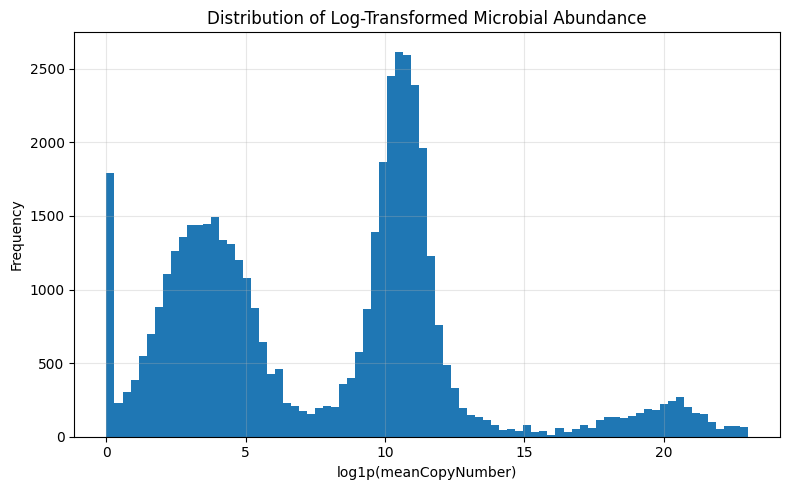

In [ ]:
raw_target = "meanCopyNumber"
target = "log_meanCopyNumber"

if raw_target not in df.columns:
    raise ValueError(f"Required target column '{raw_target}' was not found.")

print("Missing raw target values:", df[raw_target].isnull().sum())
print("Zero raw target values:", (df[raw_target] == 0).sum())

df[target] = np.log1p(df[raw_target])

target_summary = df[[raw_target, target]].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).T
display(target_summary)
target_summary.to_csv(TABLE_DIR / "target_summary.csv")

plt.figure(figsize=(8, 5))
plt.hist(df[target].dropna(), bins=80)
plt.xlabel("log1p(meanCopyNumber)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Microbial Abundance")
plt.tight_layout()
plt.savefig(FIG_DIR / "log_meanCopyNumber_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Leakage-aware cleaning and temporal features

This section removes variables that are likely to create shortcut learning, such as assay-adjacent fields, laboratory metadata, merge artifacts, duplicated identifiers, and processing fields.

In [ ]:
df_clean = df.copy()

leakage_or_noise_columns = [
    "nucleicAcidPurity",
    "deprecatedVialID",
    "dataQF_x", "dataQF_y",
    "remarks_x", "remarks_y",
    "dnaSampleCode",
    "uid_x", "uid_y",
    "processedDate_x", "processedDate_y",
    "testProtocolVersion_x", "testProtocolVersion_y",
    "namedLocation_y", "domainID_y", "siteID_y", "plotID_y",
    "collectDate_y", "geneticSampleID_y", "laboratoryName_y",
    "nucleicAcidConcentration_y", "sampleMaterial_y", "internalLabID_y",
    "meanCopyNumber", raw_target
]

# Keep the transformed target but remove the raw target from predictors.
columns_to_drop = [c for c in leakage_or_noise_columns if c in df_clean.columns and c != target]
df_clean = df_clean.drop(columns=columns_to_drop, errors="ignore")

# Restore raw target only for audit if it was dropped from df_clean, but it will not be used as a predictor.
df_clean[target] = df[target]

# Parse collection dates where available.
date_col = next((c for c in ["collectDate", "collectDate_x"] if c in df_clean.columns), None)
if date_col is not None:
    df_clean[date_col] = pd.to_datetime(df_clean[date_col], errors="coerce")
    df_clean["year_from_date"] = df_clean[date_col].dt.year
    df_clean["month"] = df_clean[date_col].dt.month

# Parse year_month where available.
if "year_month" in df_clean.columns:
    df_clean["year_month_parsed"] = pd.to_datetime(df_clean["year_month"], errors="coerce")
    if "month" not in df_clean.columns:
        df_clean["month"] = df_clean["year_month_parsed"].dt.month
    if "year_from_date" not in df_clean.columns:
        df_clean["year_from_date"] = df_clean["year_month_parsed"].dt.year

def month_to_season(month):
    if pd.isna(month):
        return np.nan
    month = int(month)
    if month in [12, 1, 2]:
        return "Summer"
    if month in [3, 4, 5]:
        return "Autumn"
    if month in [6, 7, 8]:
        return "Winter"
    return "Spring"

if "month" in df_clean.columns:
    df_clean["season"] = df_clean["month"].apply(month_to_season)

print("Shape after leakage-aware cleaning:", df_clean.shape)
print("Date column used:", date_col)

Shape after leakage-aware cleaning: (47435, 61)
Date column used: collectDate_x


## 8. Approved ecological feature set

Only ecological predictors are allowed in the modelling feature set. Identifiers such as `siteID` and `plotID` are not used as predictors; they are used only to construct transfer-aware validation splits. This separation is important for leakage-aware benchmarking.

In [ ]:
soil_features = [
    "soilInWaterpH_mean",
    "soilInCaClpH_mean",
    "soilMoisture_mean",
    "dryMassFraction_mean",
    "soilTemp",
    "sampleTopDepth",
    "sampleBottomDepth",
    "horizon"
]

climate_features = [
    "airTemp_mean",
    "precip_total",
    "humidity_mean",
    "shortwave_mean",
    "par_mean",
    "surfaceTemp_mean",
    "topWetness_mean"
]

spatial_features = [
    "field_latitude",
    "field_longitude"
]

temporal_features = [
    "month",
    "season"
]

land_cover_features = [
    "crop_type"
]

ecological_features = soil_features + climate_features + spatial_features + temporal_features + land_cover_features
available_features = [c for c in ecological_features if c in df_clean.columns]
missing_features = [c for c in ecological_features if c not in df_clean.columns]

print("Available ecological predictors:", len(available_features))
print(available_features)
print("Missing expected predictors:", missing_features)

model_mask = df_clean[target].notna()
model_df = df_clean.loc[model_mask, available_features + [target]].copy().reset_index(drop=True)

meta_cols = [c for c in ["siteID", "siteID_x", "plotID", "plotID_x", "year", "year_from_date", "year_month", "targetTaxonGroup"] if c in df_clean.columns]
model_meta = df_clean.loc[model_mask, meta_cols].copy().reset_index(drop=True)

print("Model-ready benchmark shape:", model_df.shape)
display(model_df.head())
model_df.to_csv(DATA_OUTPUT_DIR / "model_ready_ecological_subset.csv", index=False)
model_meta.to_csv(DATA_OUTPUT_DIR / "model_ready_metadata_for_validation.csv", index=False)

Available ecological predictors: 20
['soilInWaterpH_mean', 'soilInCaClpH_mean', 'soilMoisture_mean', 'dryMassFraction_mean', 'soilTemp', 'sampleTopDepth', 'sampleBottomDepth', 'horizon', 'airTemp_mean', 'precip_total', 'humidity_mean', 'shortwave_mean', 'par_mean', 'surfaceTemp_mean', 'topWetness_mean', 'field_latitude', 'field_longitude', 'month', 'season', 'crop_type']
Missing expected predictors: []
Model-ready benchmark shape: (47435, 21)


,soilInWaterpH_mean,soilInCaClpH_mean,soilMoisture_mean,dryMassFraction_mean,soilTemp,sampleTopDepth,sampleBottomDepth,horizon,airTemp_mean,precip_total,...,shortwave_mean,par_mean,surfaceTemp_mean,topWetness_mean,field_latitude,field_longitude,month,season,crop_type,log_meanCopyNumber
0,4.321667,3.216667,1.118333,0.5665,7.4,0.0,5.0,O,10.629355,126.37,...,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,5,Autumn,Mixed Forest,0.0
1,4.321667,3.216667,1.118333,0.5665,7.4,5.0,31.0,M,10.629355,126.37,...,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,5,Autumn,Mixed Forest,0.0
2,4.321667,3.216667,1.118333,0.5665,6.4,20.0,30.0,M,10.629355,126.37,...,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,5,Autumn,Mixed Forest,0.0
3,4.321667,3.216667,1.118333,0.5665,6.4,0.0,20.0,O,10.629355,126.37,...,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,5,Autumn,Mixed Forest,0.0
4,4.321667,3.216667,1.118333,0.5665,5.9,0.0,17.0,O,10.629355,126.37,...,17.069355,7.8,10.544194,0.750968,44.063889,-71.287375,5,Autumn,Mixed Forest,0.0


## 9. Validation grouping variables

The benchmark uses site and year information for evaluation only. Site grouping enables GroupKFold validation, while year enables time-aware holdout testing. These variables are not included in the predictor matrix.

In [ ]:
site_group_col = next((c for c in ["siteID", "siteID_x"] if c in model_meta.columns), None)
plot_group_col = next((c for c in ["plotID", "plotID_x"] if c in model_meta.columns), None)
year_col = next((c for c in ["year", "year_from_date"] if c in model_meta.columns), None)

print("Site grouping column:", site_group_col)
print("Plot grouping column:", plot_group_col)
print("Year column:", year_col)
display(model_meta.head())

Site grouping column: siteID
Plot grouping column: plotID_x
Year column: year


,siteID,siteID_x,plotID_x,year,year_from_date,year_month,targetTaxonGroup
0,BART,BART,BART_004,2014,2014,2014-05,fungi
1,BART,BART,BART_004,2014,2014,2014-05,fungi
2,BART,BART,BART_004,2014,2014,2014-05,fungi
3,BART,BART,BART_004,2014,2014,2014-05,fungi
4,BART,BART,BART_004,2014,2014,2014-05,fungi


## 10. Benchmark model list

This section defines the model families used in the benchmark. The list includes simple linear baselines, nonlinear tree ensembles, gradient boosting models and one stacking ensemble.

The stacking ensemble is treated carefully. It is not trained on the full dataset before validation. Instead, it is wrapped inside the same preprocessing pipeline as the other models and is fitted separately inside each random split, cross-validation fold, GroupKFold fold and time-aware holdout. This prevents the outer test data from being used by the stacking meta-learner.


In [ ]:
def get_stacking_base_names():
    """Return base models available for the stacking ensemble.

    The stack is deliberately limited to strong but diverse tabular models.
    It is only used when at least two base learners are available.
    """
    base_names = ["Random Forest", "Extra Trees"]
    if XGBOOST_AVAILABLE:
        base_names.append("XGBoost")
    if LIGHTGBM_AVAILABLE:
        base_names.append("LightGBM")
    if CATBOOST_AVAILABLE:
        base_names.append("CatBoost")
    return base_names


def available_model_names():
    names = [
        "Ridge",
        "ElasticNet",
        "Random Forest",
        "Extra Trees"
    ]
    if XGBOOST_AVAILABLE:
        names.append("XGBoost")
    if LIGHTGBM_AVAILABLE:
        names.append("LightGBM")
    if CATBOOST_AVAILABLE:
        names.append("CatBoost")
    if len(get_stacking_base_names()) >= 2:
        names.append("Stacking Ensemble")
    return names


MODEL_NAMES = available_model_names()
STACKING_BASE_NAMES = get_stacking_base_names()

model_description = pd.DataFrame({
    "Model": MODEL_NAMES,
    "Role in benchmark": [
        "Regularised linear baseline" if m == "Ridge" else
        "Sparse regularised linear baseline" if m == "ElasticNet" else
        "Bagging-based nonlinear tree ensemble" if m == "Random Forest" else
        "Highly randomised tree ensemble" if m == "Extra Trees" else
        "Boosted tree model for tabular nonlinear prediction" if m == "XGBoost" else
        "Fast gradient boosting model for structured data" if m == "LightGBM" else
        "Gradient boosting model commonly strong on heterogeneous tabular data" if m == "CatBoost" else
        "Hybrid stack trained with out-of-fold base-model predictions inside each training split"
        for m in MODEL_NAMES
    ]
})

print("Benchmark models:", MODEL_NAMES)
print("Stacking base learners:", STACKING_BASE_NAMES)
display(model_description)
model_description.to_csv(TABLE_DIR / "benchmark_model_description.csv", index=False)


Benchmark models: ['Ridge', 'ElasticNet', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble']
Stacking base learners: ['Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost']


,Model,Role in benchmark
0,Ridge,Regularised linear baseline
1,ElasticNet,Sparse regularised linear baseline
2,Random Forest,Bagging-based nonlinear tree ensemble
3,Extra Trees,Highly randomised tree ensemble
4,XGBoost,Boosted tree model for tabular nonlinear predi...
5,LightGBM,Fast gradient boosting model for structured data
6,CatBoost,Gradient boosting model commonly strong on het...
7,Stacking Ensemble,Hybrid stack trained with out-of-fold base-mod...


## 11. Reusable benchmark functions

These functions make sure every model is evaluated under the same preprocessing, metrics, and validation settings. This is the core requirement for a fair benchmark.

In [ ]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def metric_dict(y_true, y_pred):
    return {
        "R2": float(r2_score(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred)
    }


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(X, scale_numeric=False):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    if scale_numeric:
        numeric_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_pipeline = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_one_hot_encoder())
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_cols),
            ("cat", categorical_pipeline, categorical_cols)
        ],
        remainder="drop"
    )


def build_model(model_name):
    if model_name == "Ridge":
        return Ridge(alpha=1.0)

    if model_name == "ElasticNet":
        return ElasticNet(alpha=0.001, l1_ratio=0.3, max_iter=10000, random_state=SEED)

    if model_name == "Random Forest":
        return RandomForestRegressor(
            n_estimators=200,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1
        )

    if model_name == "Extra Trees":
        return ExtraTreesRegressor(
            n_estimators=200,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=-1
        )

    if model_name == "XGBoost":
        return XGBRegressor(
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1,
            tree_method="hist"
        )

    if model_name == "LightGBM":
        return LGBMRegressor(
            n_estimators=500,
            learning_rate=0.04,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1
        )

    if model_name == "CatBoost":
        return CatBoostRegressor(
            iterations=500,
            learning_rate=0.05,
            depth=6,
            loss_function="RMSE",
            random_seed=SEED,
            verbose=False
        )

    if model_name == "Stacking Ensemble":
        base_names = get_stacking_base_names()
        if len(base_names) < 2:
            raise ValueError("Stacking Ensemble requires at least two base learners.")

        estimators = []
        for base_name in base_names:
            short_name = base_name.lower().replace(" ", "_").replace("/", "_")
            estimators.append((short_name, build_model(base_name)))

        return StackingRegressor(
            estimators=estimators,
            final_estimator=Ridge(alpha=1.0),
            cv=KFold(n_splits=5, shuffle=True, random_state=SEED),
            passthrough=False,
            n_jobs=-1
        )

    raise ValueError(f"Unknown model name: {model_name}")

def build_pipeline(X, model_name):
    scale_numeric = model_name in ["Ridge", "ElasticNet"]
    return Pipeline(steps=[
        ("preprocess", build_preprocessor(X, scale_numeric=scale_numeric)),
        ("model", build_model(model_name))
    ])


def random_split_evaluation(X, y, model_name, test_size=0.2):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=SEED
    )
    pipe = build_pipeline(X_train, model_name)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return metric_dict(y_test, pred), pipe, X_train, X_test, y_train, y_test, pred


def kfold_evaluation(X, y, model_name, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    rows = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        pipe = build_pipeline(X_train, model_name)
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        rows.append({"Fold": fold, **metric_dict(y_test, pred)})

    return pd.DataFrame(rows)


def groupkfold_evaluation(X, y, groups, model_name, n_splits=5):
    valid_mask = groups.notna().values
    X_valid = X.loc[valid_mask].reset_index(drop=True)
    y_valid = y.loc[valid_mask].reset_index(drop=True)
    groups_valid = groups.loc[valid_mask].reset_index(drop=True)

    n_unique_groups = groups_valid.nunique()
    if n_unique_groups < 2:
        return pd.DataFrame([{"Fold": np.nan, "R2": np.nan, "MAE": np.nan, "RMSE": np.nan}])

    n_splits = min(n_splits, n_unique_groups)
    gkf = GroupKFold(n_splits=n_splits)
    rows = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X_valid, y_valid, groups_valid), start=1):
        X_train, X_test = X_valid.iloc[train_idx], X_valid.iloc[test_idx]
        y_train, y_test = y_valid.iloc[train_idx], y_valid.iloc[test_idx]
        pipe = build_pipeline(X_train, model_name)
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)
        rows.append({"Fold": fold, **metric_dict(y_test, pred)})

    return pd.DataFrame(rows)


def time_aware_holdout_evaluation(X, y, years, model_name):
    years_numeric = pd.to_numeric(years, errors="coerce")
    valid_mask = years_numeric.notna().values

    X_valid = X.loc[valid_mask].reset_index(drop=True)
    y_valid = y.loc[valid_mask].reset_index(drop=True)
    years_valid = years_numeric.loc[valid_mask].reset_index(drop=True)

    if years_valid.nunique() < 2:
        return {"R2": np.nan, "MAE": np.nan, "RMSE": np.nan, "Holdout_Year": np.nan}

    holdout_year = int(years_valid.max())
    train_mask = years_valid < holdout_year
    test_mask = years_valid == holdout_year

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        return {"R2": np.nan, "MAE": np.nan, "RMSE": np.nan, "Holdout_Year": holdout_year}

    X_train, X_test = X_valid.loc[train_mask], X_valid.loc[test_mask]
    y_train, y_test = y_valid.loc[train_mask], y_valid.loc[test_mask]

    pipe = build_pipeline(X_train, model_name)
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    out = metric_dict(y_test, pred)
    out["Holdout_Year"] = holdout_year
    return out


def summarize_cv(cv_df, setting_name):
    return {
        "Setting": setting_name,
        "R2": float(cv_df["R2"].mean()),
        "MAE": float(cv_df["MAE"].mean()),
        "RMSE": float(cv_df["RMSE"].mean())
    }

## 12. Helper functions for full benchmark execution

This cell runs each model under random split, K-fold cross-validation, GroupKFold by site, and time-aware holdout. The same function is reused for the global task and subgroup tasks.

In [ ]:
def run_benchmark(X, y, model_names, dataset_label, site_groups=None, years=None, n_splits=5):
    rows = []
    fold_outputs = {}
    random_artifacts = {}

    for model_name in model_names:
        print(f"Running {dataset_label}: {model_name}")

        random_metrics, pipe, X_train, X_test, y_train, y_test, pred = random_split_evaluation(X, y, model_name)
        rows.append({"Dataset": dataset_label, "Model": model_name, "Setting": "Random split", **random_metrics})
        random_artifacts[model_name] = {
            "pipeline": pipe,
            "X_train": X_train,
            "X_test": X_test,
            "y_train": y_train,
            "y_test": y_test,
            "pred": pred
        }

        kf_df = kfold_evaluation(X, y, model_name, n_splits=n_splits)
        fold_outputs[(model_name, "5-fold CV")] = kf_df
        rows.append({"Dataset": dataset_label, "Model": model_name, **summarize_cv(kf_df, "5-fold CV")})

        if site_groups is not None:
            gkf_df = groupkfold_evaluation(X, y, site_groups, model_name, n_splits=n_splits)
            fold_outputs[(model_name, "GroupKFold by site")] = gkf_df
            rows.append({"Dataset": dataset_label, "Model": model_name, **summarize_cv(gkf_df, "GroupKFold by site")})

        if years is not None:
            time_metrics = time_aware_holdout_evaluation(X, y, years, model_name)
            holdout_year = time_metrics.pop("Holdout_Year", np.nan)
            rows.append({"Dataset": dataset_label, "Model": model_name, "Setting": "Time-aware holdout", "Holdout_Year": holdout_year, **time_metrics})

    results = pd.DataFrame(rows)
    return results, fold_outputs, random_artifacts


def make_r2_pivot(results_df):
    return results_df.pivot_table(index="Model", columns="Setting", values="R2", aggfunc="mean")


def plot_r2_heatmap(pivot_df, title, filename):
    plot_df = pivot_df.copy()
    fig, ax = plt.subplots(figsize=(10, max(4, 0.45 * len(plot_df))))
    im = ax.imshow(plot_df.values, aspect="auto")
    ax.set_xticks(np.arange(plot_df.shape[1]))
    ax.set_xticklabels(plot_df.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(plot_df.shape[0]))
    ax.set_yticklabels(plot_df.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="R²")

    for i in range(plot_df.shape[0]):
        for j in range(plot_df.shape[1]):
            value = plot_df.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()


def compute_generalisation_gaps(results_df):
    rows = []
    for (dataset, model), group_df in results_df.groupby(["Dataset", "Model"]):
        values = group_df.set_index("Setting")
        random_r2 = values.loc["Random split", "R2"] if "Random split" in values.index else np.nan
        kfold_r2 = values.loc["5-fold CV", "R2"] if "5-fold CV" in values.index else np.nan
        site_r2 = values.loc["GroupKFold by site", "R2"] if "GroupKFold by site" in values.index else np.nan
        time_r2 = values.loc["Time-aware holdout", "R2"] if "Time-aware holdout" in values.index else np.nan

        rows.append({
            "Dataset": dataset,
            "Model": model,
            "Random_R2": random_r2,
            "KFold_R2": kfold_r2,
            "Site_R2": site_r2,
            "Time_R2": time_r2,
            "Site_Generalisation_Gap": random_r2 - site_r2 if pd.notna(random_r2) and pd.notna(site_r2) else np.nan,
            "Temporal_Generalisation_Gap": random_r2 - time_r2 if pd.notna(random_r2) and pd.notna(time_r2) else np.nan,
            "Mean_Transfer_R2": np.nanmean([site_r2, time_r2])
        })

    return pd.DataFrame(rows)

## 13. Global benchmark across plain and stacking model

The global benchmark tests whether one model can predict microbial abundance across all microbial groups using the same leakage-aware ecological features. This is the main model-comparison table for the benchmarking paper.

In [ ]:
X_global = model_df[available_features].copy()
y_global = model_df[target].copy()
site_groups_global = model_meta[site_group_col] if site_group_col is not None else None
years_global = model_meta[year_col] if year_col is not None else None

global_results, global_fold_outputs, global_random_artifacts = run_benchmark(
    X=X_global,
    y=y_global,
    model_names=MODEL_NAMES,
    dataset_label="Global",
    site_groups=site_groups_global,
    years=years_global,
    n_splits=5
)

display(global_results)
global_results.to_csv(TABLE_DIR / "global_extended_model_benchmark_results.csv", index=False)

Running Global: Ridge
Running Global: ElasticNet
Running Global: Random Forest
Running Global: Extra Trees
Running Global: XGBoost
Running Global: LightGBM
Running Global: CatBoost
Running Global: Stacking Ensemble


,Dataset,Model,Setting,R2,MAE,RMSE,Holdout_Year
0,Global,Ridge,Random split,0.053782,4.133080,4.856952,NaN
1,Global,Ridge,5-fold CV,0.051460,4.126208,4.844565,NaN
2,Global,Ridge,GroupKFold by site,-0.157172,4.390010,5.318139,NaN
3,Global,Ridge,Time-aware holdout,-0.093516,2.691757,3.013881,2018.0
4,Global,ElasticNet,Random split,0.053529,4.134870,4.857603,NaN
5,Global,ElasticNet,5-fold CV,0.051399,4.127672,4.844725,NaN
6,Global,ElasticNet,GroupKFold by site,-0.106167,4.318934,5.204631,NaN
7,Global,ElasticNet,Time-aware holdout,-0.087089,2.690751,3.005010,2018.0
8,Global,Random Forest,Random split,0.135808,4.154956,4.641662,NaN
9,Global,Random Forest,5-fold CV,0.150348,4.123597,4.585027,NaN


## 14. Global benchmark visualisation and model ranking

The heatmap makes the main benchmark result easy to see: a model may perform well under random split but still fail under site-aware or time-aware validation. The ranking table quantifies this using site and temporal generalisation gaps.

Setting,5-fold CV,GroupKFold by site,Random split,Time-aware holdout
Model,,,,
CatBoost,0.344200,-0.059648,0.333293,-0.090766
ElasticNet,0.051399,-0.106167,0.053529,-0.087089
Extra Trees,0.116994,-0.103077,0.103266,-0.183770
LightGBM,0.331187,-0.167043,0.319203,-0.066537
Random Forest,0.150348,-0.150366,0.135808,-0.085356
Ridge,0.051460,-0.157172,0.053782,-0.093516
Stacking Ensemble,0.445201,-0.736183,0.434687,-0.418330
XGBoost,0.320249,-0.099958,0.307568,-0.069148


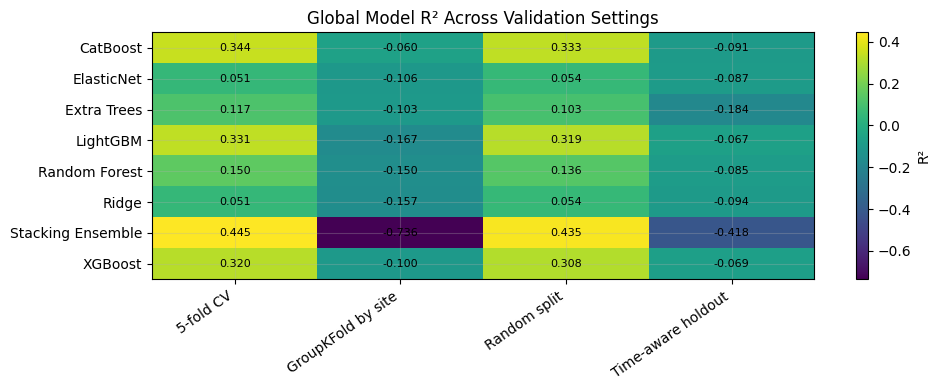

,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
6,Global,Stacking Ensemble,0.434687,0.445201,-0.736183,-0.418330,1.170871,0.853017,-0.577257
0,Global,CatBoost,0.333293,0.344200,-0.059648,-0.090766,0.392941,0.424059,-0.075207
3,Global,LightGBM,0.319203,0.331187,-0.167043,-0.066537,0.486246,0.385741,-0.116790
7,Global,XGBoost,0.307568,0.320249,-0.099958,-0.069148,0.407526,0.376716,-0.084553
4,Global,Random Forest,0.135808,0.150348,-0.150366,-0.085356,0.286174,0.221164,-0.117861
2,Global,Extra Trees,0.103266,0.116994,-0.103077,-0.183770,0.206343,0.287035,-0.143423
5,Global,Ridge,0.053782,0.051460,-0.157172,-0.093516,0.210954,0.147299,-0.125344
1,Global,ElasticNet,0.053529,0.051399,-0.106167,-0.087089,0.159696,0.140618,-0.096628


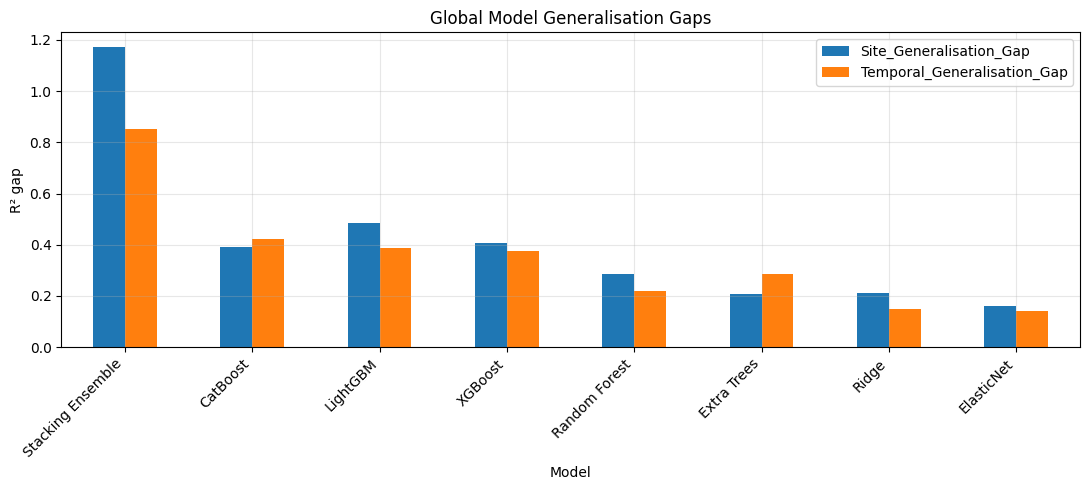

In [ ]:
global_r2_pivot = make_r2_pivot(global_results)
display(global_r2_pivot)
global_r2_pivot.to_csv(TABLE_DIR / "global_model_r2_pivot.csv")

plot_r2_heatmap(
    global_r2_pivot,
    "Global Model R² Across Validation Settings",
    "global_model_r2_heatmap.png"
)

global_gap_df = compute_generalisation_gaps(global_results).sort_values("Random_R2", ascending=False)
display(global_gap_df)
global_gap_df.to_csv(TABLE_DIR / "global_model_generalisation_gaps.csv", index=False)

plot_cols = ["Site_Generalisation_Gap", "Temporal_Generalisation_Gap"]
ax = global_gap_df.set_index("Model")[plot_cols].plot(kind="bar", figsize=(11, 5))
ax.set_ylabel("R² gap")
ax.set_title("Global Model Generalisation Gaps")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "global_model_generalisation_gaps.png", dpi=300, bbox_inches="tight")
plt.show()

## 15. Feature-block ablation using XGBoost

The ablation study tests whether predictive signal mainly comes from soil, climate, spatial, temporal, or combined ecological feature groups. XGBoost is used here because it is a strong and stable tabular baseline.

,Model,Feature_Set,Number_of_Features_Before_Encoding,R2,MAE,RMSE
0,XGBoost,Soil only,8,0.264522,3.847473,4.282064
1,XGBoost,Climate only,7,0.336232,3.658071,4.067959
2,XGBoost,Soil + Climate,15,0.304769,3.756929,4.163254
3,XGBoost,Soil + Climate + Spatial,17,0.305009,3.753652,4.162534
4,XGBoost,Soil + Climate + Spatial + Temporal,19,0.306531,3.747658,4.157974
5,XGBoost,Full ecological set,20,0.307568,3.746450,4.154864


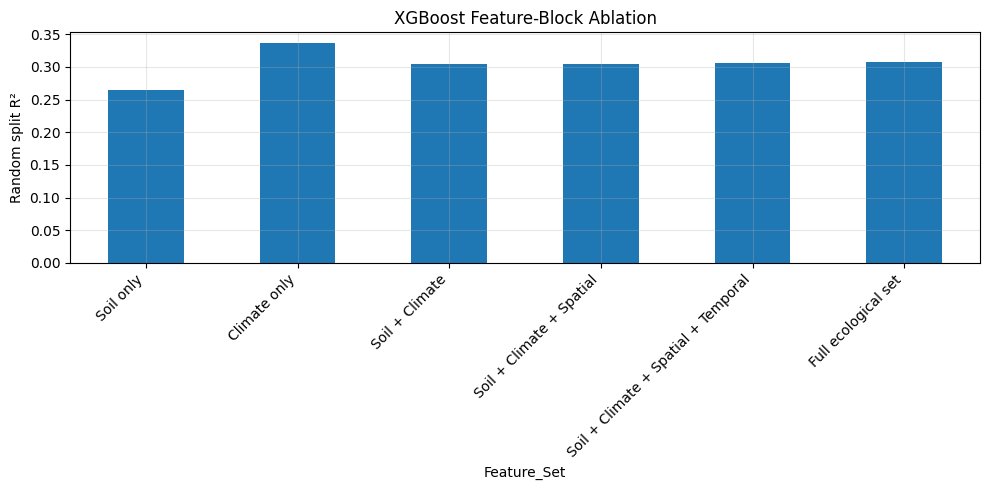

In [ ]:
ablation_model = "XGBoost" if XGBOOST_AVAILABLE else MODEL_NAMES[0]

feature_set_definitions = {
    "Soil only": soil_features,
    "Climate only": climate_features,
    "Soil + Climate": soil_features + climate_features,
    "Soil + Climate + Spatial": soil_features + climate_features + spatial_features,
    "Soil + Climate + Spatial + Temporal": soil_features + climate_features + spatial_features + temporal_features,
    "Full ecological set": ecological_features
}

ablation_rows = []
for feature_set_name, feature_list in feature_set_definitions.items():
    selected_features = [c for c in feature_list if c in df_clean.columns]
    if len(selected_features) == 0:
        continue

    X_ablation = model_df[selected_features].copy()
    y_ablation = model_df[target].copy()
    metrics, _, _, _, _, _, _ = random_split_evaluation(X_ablation, y_ablation, ablation_model)
    ablation_rows.append({
        "Model": ablation_model,
        "Feature_Set": feature_set_name,
        "Number_of_Features_Before_Encoding": len(selected_features),
        **metrics
    })

ablation_results = pd.DataFrame(ablation_rows)
display(ablation_results)
ablation_results.to_csv(TABLE_DIR / "feature_block_ablation_results.csv", index=False)

ax = ablation_results.plot(x="Feature_Set", y="R2", kind="bar", legend=False, figsize=(10, 5))
ax.set_ylabel("Random split R²")
ax.set_title(f"{ablation_model} Feature-Block Ablation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_block_ablation_r2.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Prepare subgroup benchmark datasets

Subgroup modelling checks whether biologically coherent microbial groups are easier to model than a mixed global target. This is important because fungi and bacteria/archaea may respond differently to soil and climate drivers.

In [ ]:
if "targetTaxonGroup" not in model_meta.columns:
    raise ValueError("targetTaxonGroup column is required for subgroup benchmarking.")

taxon_lower = model_meta["targetTaxonGroup"].astype(str).str.lower()
fungi_mask = taxon_lower == "fungi"
bacteria_archaea_mask = taxon_lower.isin(["bacteria and archaea", "bacteria", "archaea"])

print("Fungi rows:", int(fungi_mask.sum()))
print("Bacteria/Archaea rows:", int(bacteria_archaea_mask.sum()))

subgroup_summary = pd.DataFrame({
    "Subgroup": ["Fungi", "Bacteria/Archaea"],
    "Rows": [int(fungi_mask.sum()), int(bacteria_archaea_mask.sum())]
})
display(subgroup_summary)
subgroup_summary.to_csv(TABLE_DIR / "subgroup_dataset_summary.csv", index=False)

Fungi rows: 22776
Bacteria/Archaea rows: 24659


,Subgroup,Rows
0,Fungi,22776
1,Bacteria/Archaea,24659


## 17. Subgroup benchmark with selected advanced models

To keep runtime reasonable, subgroup benchmarking focuses on the strongest advanced tabular models and the hybrid blend. This tests whether stronger model families improve subgroup prediction or reduce the spatial and temporal transfer gap.

In [ ]:
RUN_ALL_MODELS_FOR_SUBGROUPS = False

if RUN_ALL_MODELS_FOR_SUBGROUPS:
    SUBGROUP_MODEL_NAMES = MODEL_NAMES
else:
    preferred_subgroup_models = ["XGBoost", "LightGBM", "CatBoost", "Stacking Ensemble"]
    SUBGROUP_MODEL_NAMES = [m for m in preferred_subgroup_models if m in MODEL_NAMES]
    if len(SUBGROUP_MODEL_NAMES) == 0:
        SUBGROUP_MODEL_NAMES = MODEL_NAMES[:3]

print("Subgroup models:", SUBGROUP_MODEL_NAMES)

subgroup_results_list = []
subgroup_random_artifacts = {}

subgroup_definitions = {
    "Fungi": fungi_mask,
    "Bacteria/Archaea": bacteria_archaea_mask
}

for subgroup_name, subgroup_mask in subgroup_definitions.items():
    X_sub = model_df.loc[subgroup_mask, available_features].reset_index(drop=True)
    y_sub = model_df.loc[subgroup_mask, target].reset_index(drop=True)
    meta_sub = model_meta.loc[subgroup_mask].reset_index(drop=True)

    site_groups_sub = meta_sub[site_group_col] if site_group_col is not None else None
    years_sub = meta_sub[year_col] if year_col is not None else None

    results_sub, folds_sub, artifacts_sub = run_benchmark(
        X=X_sub,
        y=y_sub,
        model_names=SUBGROUP_MODEL_NAMES,
        dataset_label=subgroup_name,
        site_groups=site_groups_sub,
        years=years_sub,
        n_splits=5
    )

    subgroup_results_list.append(results_sub)
    subgroup_random_artifacts[subgroup_name] = artifacts_sub

subgroup_results = pd.concat(subgroup_results_list, ignore_index=True)
display(subgroup_results)
subgroup_results.to_csv(TABLE_DIR / "subgroup_selected_model_benchmark_results.csv", index=False)

Subgroup models: ['XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble']
Running Fungi: XGBoost
Running Fungi: LightGBM
Running Fungi: CatBoost
Running Fungi: Stacking Ensemble
Running Bacteria/Archaea: XGBoost
Running Bacteria/Archaea: LightGBM
Running Bacteria/Archaea: CatBoost
Running Bacteria/Archaea: Stacking Ensemble


,Dataset,Model,Setting,R2,MAE,RMSE,Holdout_Year
0,Fungi,XGBoost,Random split,0.758670,0.819203,1.334207,NaN
1,Fungi,XGBoost,5-fold CV,0.743676,0.820638,1.373042,NaN
2,Fungi,XGBoost,GroupKFold by site,-0.110417,1.871527,2.767479,NaN
3,Fungi,XGBoost,Time-aware holdout,-1.283253,1.610575,1.938786,2018.0
4,Fungi,LightGBM,Random split,0.778153,0.794562,1.279217,NaN
5,Fungi,LightGBM,5-fold CV,0.762469,0.803177,1.321714,NaN
6,Fungi,LightGBM,GroupKFold by site,-0.242393,1.987979,2.917159,NaN
7,Fungi,LightGBM,Time-aware holdout,-1.117259,1.522849,1.866981,2018.0
8,Fungi,CatBoost,Random split,0.750287,0.886186,1.357180,NaN
9,Fungi,CatBoost,5-fold CV,0.736610,0.892347,1.391907,NaN


## 18. Subgroup benchmark visualisation and gap analysis

These tables and plots compare whether the advanced models and hybrid blend perform better for biologically separated targets. The key interpretation is not only which model has the highest random R², but whether any model reduces the transfer gap.

,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
2,Bacteria/Archaea,Stacking Ensemble,0.571647,0.602307,-0.574185,-2.168213,1.145832,2.739860,-1.371199
0,Bacteria/Archaea,CatBoost,0.558089,0.581205,-0.191817,-0.853996,0.749906,1.412085,-0.522907
1,Bacteria/Archaea,LightGBM,0.554375,0.586787,-0.274188,-1.302172,0.828563,1.856547,-0.788180
3,Bacteria/Archaea,XGBoost,0.529181,0.563700,-0.335142,-2.495942,0.864323,3.025123,-1.415542
6,Fungi,Stacking Ensemble,0.784651,0.768600,-0.638911,-1.608207,1.423562,2.392858,-1.123559
5,Fungi,LightGBM,0.778153,0.762469,-0.242393,-1.117259,1.020546,1.895412,-0.679826
7,Fungi,XGBoost,0.758670,0.743676,-0.110417,-1.283253,0.869087,2.041923,-0.696835
4,Fungi,CatBoost,0.750287,0.736610,-0.104057,-1.080701,0.854344,1.830988,-0.592379


Setting,5-fold CV,GroupKFold by site,Random split,Time-aware holdout
Model,,,,
CatBoost,0.736610,-0.104057,0.750287,-1.080701
LightGBM,0.762469,-0.242393,0.778153,-1.117259
Stacking Ensemble,0.768600,-0.638911,0.784651,-1.608207
XGBoost,0.743676,-0.110417,0.758670,-1.283253


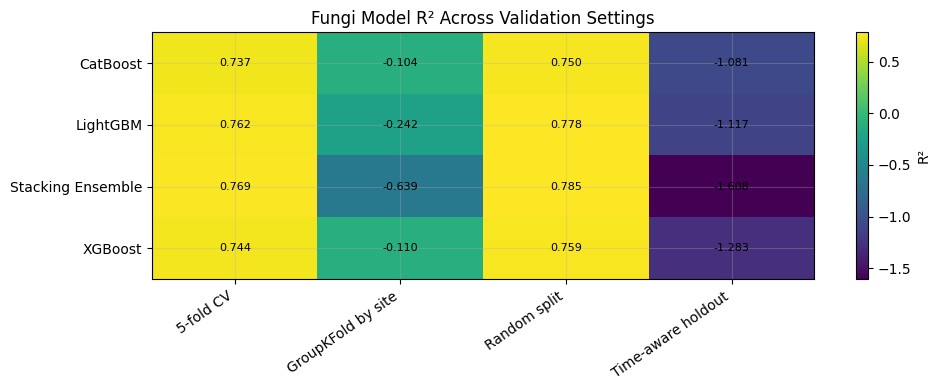

Setting,5-fold CV,GroupKFold by site,Random split,Time-aware holdout
Model,,,,
CatBoost,0.581205,-0.191817,0.558089,-0.853996
LightGBM,0.586787,-0.274188,0.554375,-1.302172
Stacking Ensemble,0.602307,-0.574185,0.571647,-2.168213
XGBoost,0.563700,-0.335142,0.529181,-2.495942


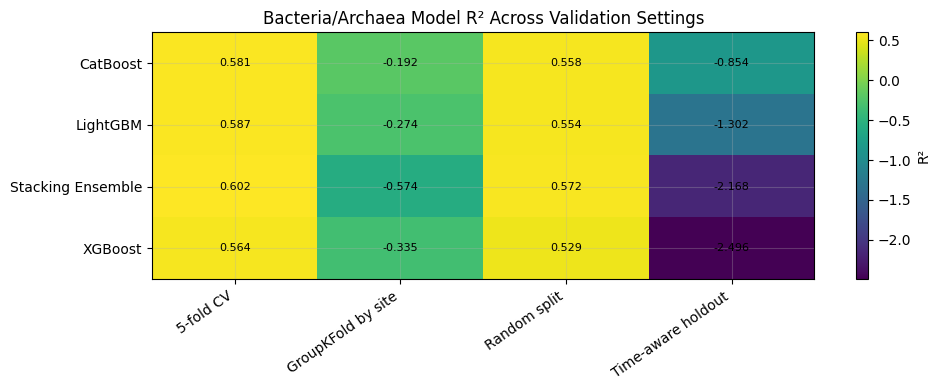

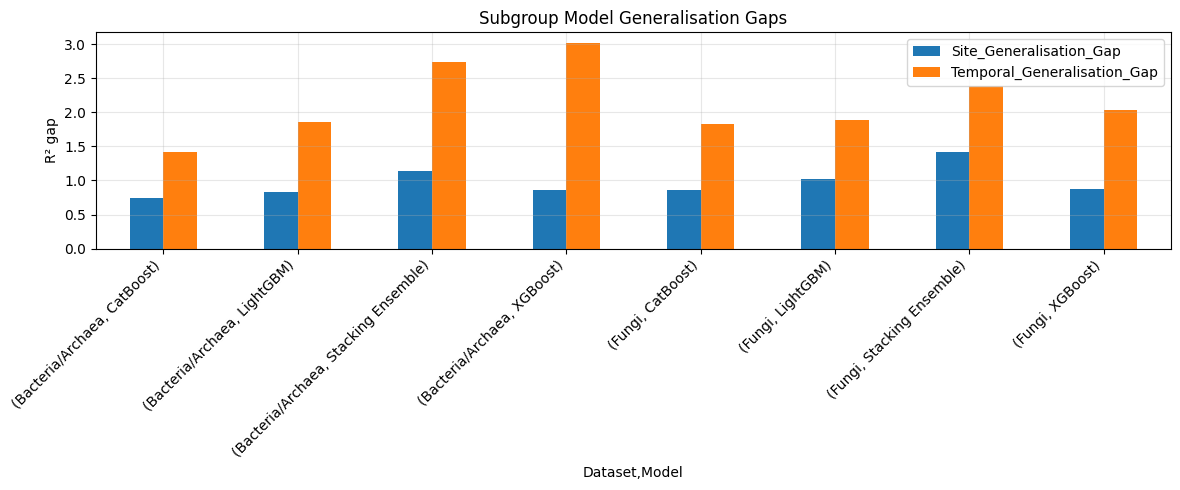

In [ ]:
subgroup_gap_df = compute_generalisation_gaps(subgroup_results).sort_values(["Dataset", "Random_R2"], ascending=[True, False])
display(subgroup_gap_df)
subgroup_gap_df.to_csv(TABLE_DIR / "subgroup_model_generalisation_gaps.csv", index=False)

for subgroup_name in subgroup_results["Dataset"].unique():
    subgroup_pivot = make_r2_pivot(subgroup_results[subgroup_results["Dataset"] == subgroup_name])
    display(subgroup_pivot)
    subgroup_pivot.to_csv(TABLE_DIR / f"{subgroup_name.lower().replace('/', '_').replace(' ', '_')}_model_r2_pivot.csv")
    plot_r2_heatmap(
        subgroup_pivot,
        f"{subgroup_name} Model R² Across Validation Settings",
        f"{subgroup_name.lower().replace('/', '_').replace(' ', '_')}_model_r2_heatmap.png"
    )

ax = subgroup_gap_df.pivot_table(
    index=["Dataset", "Model"],
    values=["Site_Generalisation_Gap", "Temporal_Generalisation_Gap"],
    aggfunc="mean"
).plot(kind="bar", figsize=(12, 5))
ax.set_ylabel("R² gap")
ax.set_title("Subgroup Model Generalisation Gaps")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "subgroup_model_generalisation_gaps.png", dpi=300, bbox_inches="tight")
plt.show()

## 19. Combined benchmark summary

This cell we have run to make our paper writing easier. To explain results better.

In [ ]:
combined_results = pd.concat([global_results, subgroup_results], ignore_index=True)
combined_results.to_csv(TABLE_DIR / "combined_global_and_subgroup_benchmark_results.csv", index=False)

gap_all_df = compute_generalisation_gaps(combined_results).sort_values(["Dataset", "Random_R2"], ascending=[True, False])
display(gap_all_df)
gap_all_df.to_csv(TABLE_DIR / "combined_generalisation_gap_summary.csv", index=False)

best_random_by_dataset = gap_all_df.sort_values("Random_R2", ascending=False).groupby("Dataset").head(3)
display(best_random_by_dataset)
best_random_by_dataset.to_csv(TABLE_DIR / "top_models_by_random_r2_each_dataset.csv", index=False)

best_transfer_by_dataset = gap_all_df.sort_values("Mean_Transfer_R2", ascending=False).groupby("Dataset").head(3)
display(best_transfer_by_dataset)
best_transfer_by_dataset.to_csv(TABLE_DIR / "top_models_by_transfer_r2_each_dataset.csv", index=False)

,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
2,Bacteria/Archaea,Stacking Ensemble,0.571647,0.602307,-0.574185,-2.168213,1.145832,2.739860,-1.371199
0,Bacteria/Archaea,CatBoost,0.558089,0.581205,-0.191817,-0.853996,0.749906,1.412085,-0.522907
1,Bacteria/Archaea,LightGBM,0.554375,0.586787,-0.274188,-1.302172,0.828563,1.856547,-0.788180
3,Bacteria/Archaea,XGBoost,0.529181,0.563700,-0.335142,-2.495942,0.864323,3.025123,-1.415542
6,Fungi,Stacking Ensemble,0.784651,0.768600,-0.638911,-1.608207,1.423562,2.392858,-1.123559
5,Fungi,LightGBM,0.778153,0.762469,-0.242393,-1.117259,1.020546,1.895412,-0.679826
7,Fungi,XGBoost,0.758670,0.743676,-0.110417,-1.283253,0.869087,2.041923,-0.696835
4,Fungi,CatBoost,0.750287,0.736610,-0.104057,-1.080701,0.854344,1.830988,-0.592379
14,Global,Stacking Ensemble,0.434687,0.445201,-0.736183,-0.418330,1.170871,0.853017,-0.577257
8,Global,CatBoost,0.333293,0.344200,-0.059648,-0.090766,0.392941,0.424059,-0.075207


,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
6,Fungi,Stacking Ensemble,0.784651,0.768600,-0.638911,-1.608207,1.423562,2.392858,-1.123559
5,Fungi,LightGBM,0.778153,0.762469,-0.242393,-1.117259,1.020546,1.895412,-0.679826
7,Fungi,XGBoost,0.758670,0.743676,-0.110417,-1.283253,0.869087,2.041923,-0.696835
2,Bacteria/Archaea,Stacking Ensemble,0.571647,0.602307,-0.574185,-2.168213,1.145832,2.739860,-1.371199
0,Bacteria/Archaea,CatBoost,0.558089,0.581205,-0.191817,-0.853996,0.749906,1.412085,-0.522907
1,Bacteria/Archaea,LightGBM,0.554375,0.586787,-0.274188,-1.302172,0.828563,1.856547,-0.788180
14,Global,Stacking Ensemble,0.434687,0.445201,-0.736183,-0.418330,1.170871,0.853017,-0.577257
8,Global,CatBoost,0.333293,0.344200,-0.059648,-0.090766,0.392941,0.424059,-0.075207
11,Global,LightGBM,0.319203,0.331187,-0.167043,-0.066537,0.486246,0.385741,-0.116790


,Dataset,Model,Random_R2,KFold_R2,Site_R2,Time_R2,Site_Generalisation_Gap,Temporal_Generalisation_Gap,Mean_Transfer_R2
8,Global,CatBoost,0.333293,0.344200,-0.059648,-0.090766,0.392941,0.424059,-0.075207
15,Global,XGBoost,0.307568,0.320249,-0.099958,-0.069148,0.407526,0.376716,-0.084553
9,Global,ElasticNet,0.053529,0.051399,-0.106167,-0.087089,0.159696,0.140618,-0.096628
0,Bacteria/Archaea,CatBoost,0.558089,0.581205,-0.191817,-0.853996,0.749906,1.412085,-0.522907
4,Fungi,CatBoost,0.750287,0.736610,-0.104057,-1.080701,0.854344,1.830988,-0.592379
5,Fungi,LightGBM,0.778153,0.762469,-0.242393,-1.117259,1.020546,1.895412,-0.679826
7,Fungi,XGBoost,0.758670,0.743676,-0.110417,-1.283253,0.869087,2.041923,-0.696835
1,Bacteria/Archaea,LightGBM,0.554375,0.586787,-0.274188,-1.302172,0.828563,1.856547,-0.788180
2,Bacteria/Archaea,Stacking Ensemble,0.571647,0.602307,-0.574185,-2.168213,1.145832,2.739860,-1.371199


## 20. SHAP explanation for the fungi XGBoost model

The SHAP section is kept as supporting evidence, not as a separate research direction. It checks whether the strongest interpretable subgroup model uses ecologically plausible predictors. The top-feature table, SHAP summary plot, and SHAP bar plot are sufficient for the paper because they show both feature ranking and direction of effects.

,Feature,Mean_Abs_SHAP
1,soilInCaClpH_mean,0.454994
14,field_latitude,0.296514
0,soilInWaterpH_mean,0.273789
8,precip_total,0.191264
15,field_longitude,0.155175
7,airTemp_mean,0.151064
13,topWetness_mean,0.141647
4,soilTemp,0.134779
9,humidity_mean,0.125513
10,shortwave_mean,0.117838


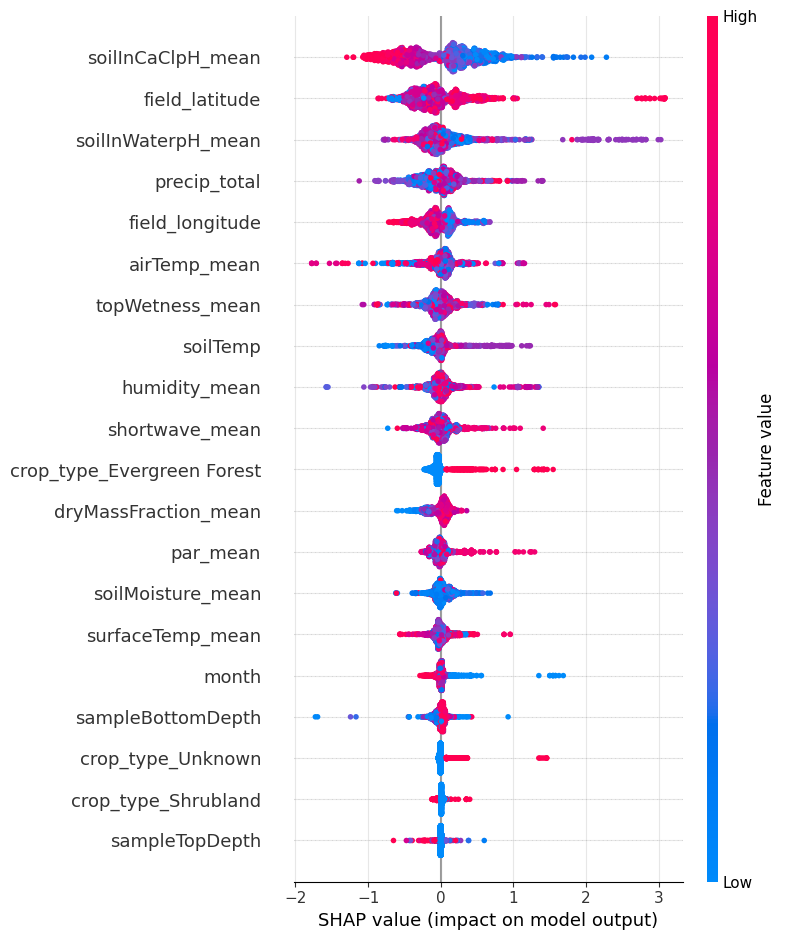

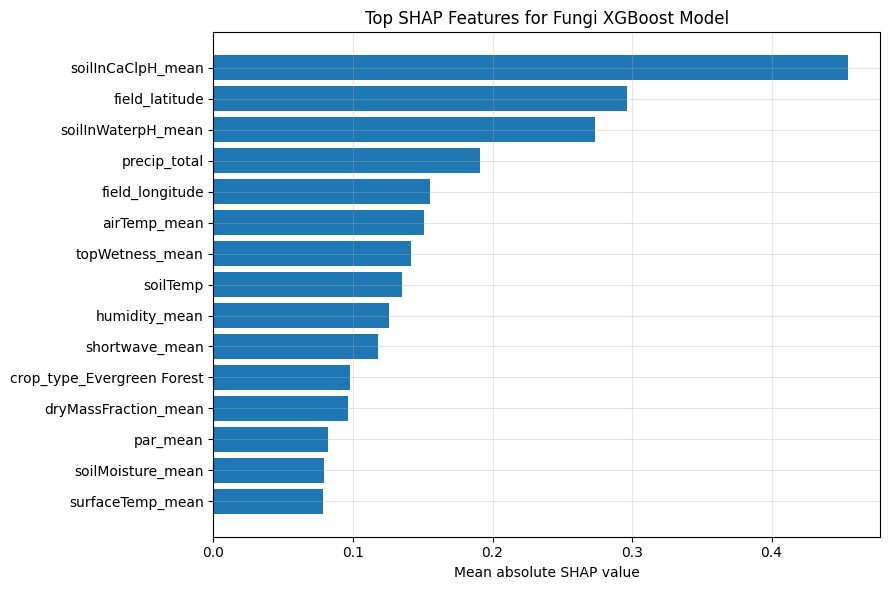

In [ ]:
if not SHAP_AVAILABLE:
    print("SHAP is not available. Install shap and rerun this cell if you need explainability figures.")
elif "Fungi" not in subgroup_random_artifacts:
    print("Fungi subgroup artifacts were not found. Rerun the subgroup benchmark first.")
elif "XGBoost" not in subgroup_random_artifacts["Fungi"]:
    print("XGBoost was not run for the fungi subgroup. Add XGBoost to SUBGROUP_MODEL_NAMES and rerun.")
else:
    fungi_xgb_pipe = subgroup_random_artifacts["Fungi"]["XGBoost"]["pipeline"]
    X_test_fungi = subgroup_random_artifacts["Fungi"]["XGBoost"]["X_test"]

    preprocess = fungi_xgb_pipe.named_steps["preprocess"]
    xgb_model = fungi_xgb_pipe.named_steps["model"]

    X_test_transformed = preprocess.transform(X_test_fungi)
    feature_names = preprocess.get_feature_names_out()

    sample_size = min(2000, X_test_transformed.shape[0])
    rng = np.random.default_rng(SEED)
    sample_idx = rng.choice(X_test_transformed.shape[0], size=sample_size, replace=False)
    X_shap = X_test_transformed[sample_idx]

    explainer = shap.TreeExplainer(xgb_model)
    shap_values = explainer.shap_values(X_shap)

    clean_feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance_df = pd.DataFrame({
        "Feature": clean_feature_names,
        "Mean_Abs_SHAP": mean_abs_shap
    }).sort_values("Mean_Abs_SHAP", ascending=False)

    display(shap_importance_df.head(20))
    shap_importance_df.to_csv(TABLE_DIR / "fungi_xgboost_shap_importance.csv", index=False)

    plt.figure(figsize=(9, 6))
    shap.summary_plot(shap_values, X_shap, feature_names=clean_feature_names, show=False, max_display=20)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fungi_xgboost_shap_summary.png", dpi=300, bbox_inches="tight")
    plt.show()

    top_shap = shap_importance_df.head(15).iloc[::-1]
    plt.figure(figsize=(9, 6))
    plt.barh(top_shap["Feature"], top_shap["Mean_Abs_SHAP"])
    plt.xlabel("Mean absolute SHAP value")
    plt.title("Top SHAP Features for Fungi XGBoost Model")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fungi_xgboost_top_shap_features.png", dpi=300, bbox_inches="tight")
    plt.show()

## 21. Artifact inventory

This final table lists the main outputs produced by the benchmark notebook. These are the tables and figures most useful for writing the paper.

In [ ]:
artifact_inventory = pd.DataFrame({
    "Artifact": [
        "dataset_summary.csv",
        "column_inventory.csv",
        "benchmark_model_description.csv",
        "global_extended_model_benchmark_results.csv",
        "global_model_r2_heatmap.png",
        "global_model_generalisation_gaps.csv",
        "feature_block_ablation_results.csv",
        "subgroup_selected_model_benchmark_results.csv",
        "subgroup_model_generalisation_gaps.csv",
        "combined_global_and_subgroup_benchmark_results.csv",
        "combined_generalisation_gap_summary.csv",
        "fungi_xgboost_shap_importance.csv",
        "fungi_xgboost_shap_summary.png",
        "fungi_xgboost_top_shap_features.png"
    ],
    "Purpose": [
        "Dataset size, shape, duplicates and missingness",
        "Column-level audit for reproducibility",
        "Plain and stacking model list with benchmark role",
        "Main global comparison across all models and validation settings",
        "Visual comparison of global R² across validation settings",
        "Site and temporal generalisation gaps for global models",
        "Feature-group contribution analysis",
        "Subgroup benchmark using selected advanced and stacking model",
        "Transfer-gap analysis for subgroup models",
        "Combined table for global and subgroup results",
        "Main table for random, site-aware and time-aware gap reporting",
        "Feature attribution table for fungi XGBoost",
        "SHAP summary plot showing feature importance and direction",
        "SHAP bar plot showing top ecological drivers"
    ]
})

display(artifact_inventory)
artifact_inventory.to_csv(TABLE_DIR / "artifact_inventory.csv", index=False)
print("Extended leakage-aware benchmark notebook completed.")

,Artifact,Purpose
0,dataset_summary.csv,"Dataset size, shape, duplicates and missingness"
1,column_inventory.csv,Column-level audit for reproducibility
2,benchmark_model_description.csv,Plain and stacking model list with benchmark role
3,global_extended_model_benchmark_results.csv,Main global comparison across all models and v...
4,global_model_r2_heatmap.png,Visual comparison of global R² across validati...
5,global_model_generalisation_gaps.csv,Site and temporal generalisation gaps for glob...
6,feature_block_ablation_results.csv,Feature-group contribution analysis
7,subgroup_selected_model_benchmark_results.csv,Subgroup benchmark using selected advanced and...
8,subgroup_model_generalisation_gaps.csv,Transfer-gap analysis for subgroup models
9,combined_global_and_subgroup_benchmark_results...,Combined table for global and subgroup results


Extended leakage-aware benchmark notebook completed.
